In [1]:
# Install required packages (run once)
!pip install pandas numpy scikit-learn matplotlib seaborn imbalanced-learn -q

In [2]:
# ── Common imports ────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 1.1 · Load & explore the data

In [3]:
df = pd.read_csv('credit_card_fraud_10k.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (10000, 10)


,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  str    
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), str(1)
memory usage: 781.4 KB


In [5]:
df.describe()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,2886.89568,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,1.00000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,2500.75000,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,5000.50000,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,7500.25000,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,10000.00000,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000


is_fraud
0    9849
1     151
Name: count, dtype: int64

Fraud rate: 1.51%


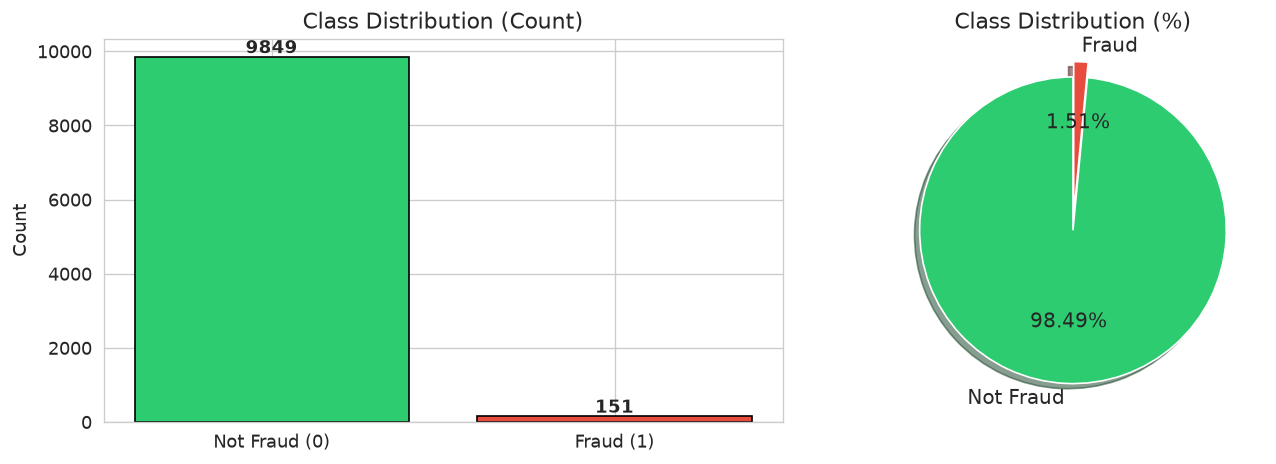

In [6]:
# ── Class distribution ────────────────────────────────────────
fraud_counts = df['is_fraud'].value_counts()
print(fraud_counts)
print(f'\nFraud rate: {fraud_counts[1] / len(df) * 100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Not Fraud (0)', 'Fraud (1)'], fraud_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Class Distribution (Count)')
axes[0].set_ylabel('Count')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(fraud_counts.values, labels=['Not Fraud', 'Fraud'], colors=colors,
            autopct='%1.2f%%', startangle=90, explode=(0, 0.1),
            shadow=True, textprops={'fontsize': 12})
axes[1].set_title('Class Distribution (%)')

plt.tight_layout()
plt.show()

### 1.2 · Feature engineering & preprocessing

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Encode categorical column
le = LabelEncoder()
df['merchant_category_enc'] = le.fit_transform(df['merchant_category'])

# Features & target
feature_cols = ['amount', 'transaction_hour', 'merchant_category_enc',
                'foreign_transaction', 'location_mismatch',
                'device_trust_score', 'velocity_last_24h', 'cardholder_age']

X = df[feature_cols].copy()
y = df['is_fraud'].copy()

# Train / test split (stratified to preserve fraud ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples')
print(f'Train fraud rate: {y_train.mean()*100:.2f}%')
print(f'Test  fraud rate: {y_test.mean()*100:.2f}%')

# Scale continuous features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Train: 8000 samples  |  Test: 2000 samples
Train fraud rate: 1.51%
Test  fraud rate: 1.50%


### 1.3 · Baseline Random Forest (no imbalance handling)

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve, f1_score)

# Baseline — default RF
rf_base = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_base.fit(X_train_scaled, y_train)
y_pred_base = rf_base.predict(X_test_scaled)
y_prob_base = rf_base.predict_proba(X_test_scaled)[:, 1]

print('=== Baseline Random Forest ===')
print(classification_report(y_test, y_pred_base, target_names=['Not Fraud', 'Fraud']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_prob_base):.4f}')
print(f'PR-AUC  : {average_precision_score(y_test, y_prob_base):.4f}')

=== Baseline Random Forest ===
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00      1970
       Fraud       1.00      0.80      0.89        30

    accuracy                           1.00      2000
   macro avg       1.00      0.90      0.94      2000
weighted avg       1.00      1.00      1.00      2000

ROC-AUC : 1.0000
PR-AUC  : 0.9989


In [9]:
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

# Strategy 1: class_weight='balanced'
rf_cw = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                               random_state=RANDOM_STATE)
rf_cw.fit(X_train_scaled, y_train)
y_pred_cw = rf_cw.predict(X_test_scaled)
y_prob_cw = rf_cw.predict_proba(X_test_scaled)[:, 1]

# Strategy 2: SMOTE
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)
print(f'After SMOTE: {np.bincount(y_train_sm)}')

rf_smote = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_smote.fit(X_train_sm, y_train_sm)
y_pred_sm = rf_smote.predict(X_test_scaled)
y_prob_sm = rf_smote.predict_proba(X_test_scaled)[:, 1]

# Strategy 3: SMOTE + Tomek Links
smt = SMOTETomek(random_state=RANDOM_STATE)
X_train_smt, y_train_smt = smt.fit_resample(X_train_scaled, y_train)
print(f'After SMOTE+Tomek: {np.bincount(y_train_smt)}')

rf_smt = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_smt.fit(X_train_smt, y_train_smt)
y_pred_smt = rf_smt.predict(X_test_scaled)
y_prob_smt = rf_smt.predict_proba(X_test_scaled)[:, 1]

After SMOTE: [7879 7879]
After SMOTE+Tomek: [7879 7879]


In [10]:
# ── Compare all strategies ────────────────────────────────────
strategies = {
    'Baseline':        (y_pred_base, y_prob_base),
    'class_weight':    (y_pred_cw,   y_prob_cw),
    'SMOTE':           (y_pred_sm,   y_prob_sm),
    'SMOTE+Tomek':     (y_pred_smt,  y_prob_smt),
}

rows = []
for name, (yp, yprob) in strategies.items():
    rows.append({
        'Strategy':  name,
        'F1 (Fraud)': f1_score(y_test, yp, pos_label=1),
        'ROC-AUC':    roc_auc_score(y_test, yprob),
        'PR-AUC':     average_precision_score(y_test, yprob),
    })

comparison_df = pd.DataFrame(rows).set_index('Strategy')
comparison_df.style.highlight_max(axis=0, color='#a8e6cf').format('{:.4f}')

,F1 (Fraud),ROC-AUC,PR-AUC
Strategy,,,
Baseline,0.8889,1.0000,0.9989
class_weight,0.9091,1.0000,0.9989
SMOTE,0.8727,0.9993,0.9539
SMOTE+Tomek,0.8727,0.9993,0.9539


### 1.5 · Hyperparameter tuning with RandomizedSearchCV

We tune on the **best resampling strategy** from above using `f1` as the
scoring metric (because accuracy is misleading on imbalanced data).

In [11]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform

# Pick the best resampled training set
best_strategy = comparison_df['F1 (Fraud)'].idxmax()
print(f'Best strategy: {best_strategy}')

resample_map = {
    'Baseline':     (X_train_scaled, y_train),
    'class_weight': (X_train_scaled, y_train),
    'SMOTE':        (X_train_sm,     y_train_sm),
    'SMOTE+Tomek':  (X_train_smt,    y_train_smt),
}
X_tune, y_tune = resample_map[best_strategy]

# Hyperparameter search space
param_dist = {
    'n_estimators':      randint(100, 500),
    'max_depth':         [5, 10, 15, 20, 25, None],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf':  randint(1, 10),
    'max_features':      ['sqrt', 'log2', 0.3, 0.5, 0.7],
    'bootstrap':         [True, False],
}

# Add class_weight if that was the winning strategy
if best_strategy == 'class_weight':
    param_dist['class_weight'] = ['balanced', 'balanced_subsample']

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_distributions=param_dist,
    n_iter=50,
    scoring='f1',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

search.fit(X_tune, y_tune)

print(f'\nBest F1 (CV): {search.best_score_:.4f}')
print(f'Best params : {search.best_params_}')

Best strategy: class_weight
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best F1 (CV): 0.9505
Best params : {'bootstrap': True, 'class_weight': 'balanced', 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 497}


In [12]:
# ── Evaluate tuned model on hold-out test set ─────────────────
rf_tuned = search.best_estimator_
y_pred_tuned = rf_tuned.predict(X_test_scaled)
y_prob_tuned = rf_tuned.predict_proba(X_test_scaled)[:, 1]

print('=== Tuned Random Forest — Test Set ===')
print(classification_report(y_test, y_pred_tuned, target_names=['Not Fraud', 'Fraud']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_prob_tuned):.4f}')
print(f'PR-AUC  : {average_precision_score(y_test, y_prob_tuned):.4f}')

=== Tuned Random Forest — Test Set ===
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00      1970
       Fraud       1.00      1.00      1.00        30

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

ROC-AUC : 1.0000
PR-AUC  : 1.0000


### 1.6 · Visualization: Confusion matrices, ROC & PR curves, feature importance

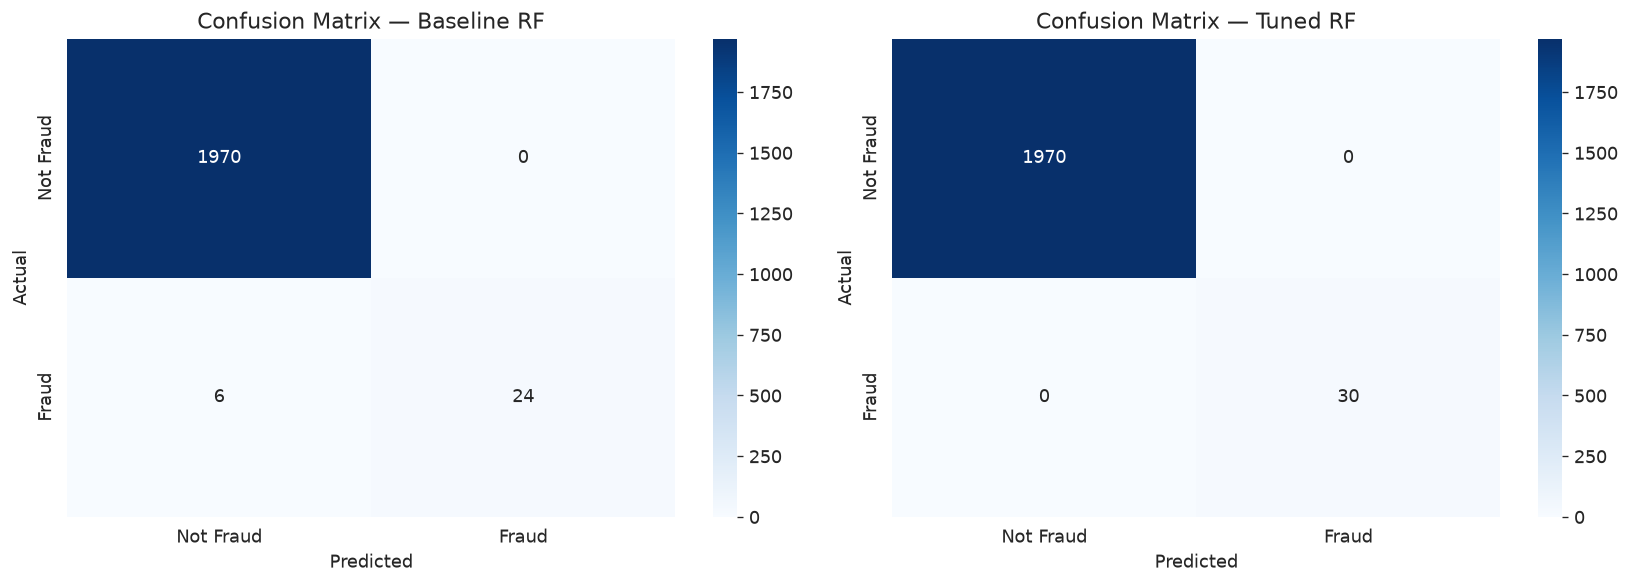

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Confusion matrices side-by-side ───────────────────────────
for ax, (title, yp) in zip(axes, [('Baseline RF', y_pred_base),
                                    ('Tuned RF', y_pred_tuned)]):
    cm = confusion_matrix(y_test, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Fraud', 'Fraud'],
                yticklabels=['Not Fraud', 'Fraud'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {title}')

plt.tight_layout()
plt.show()

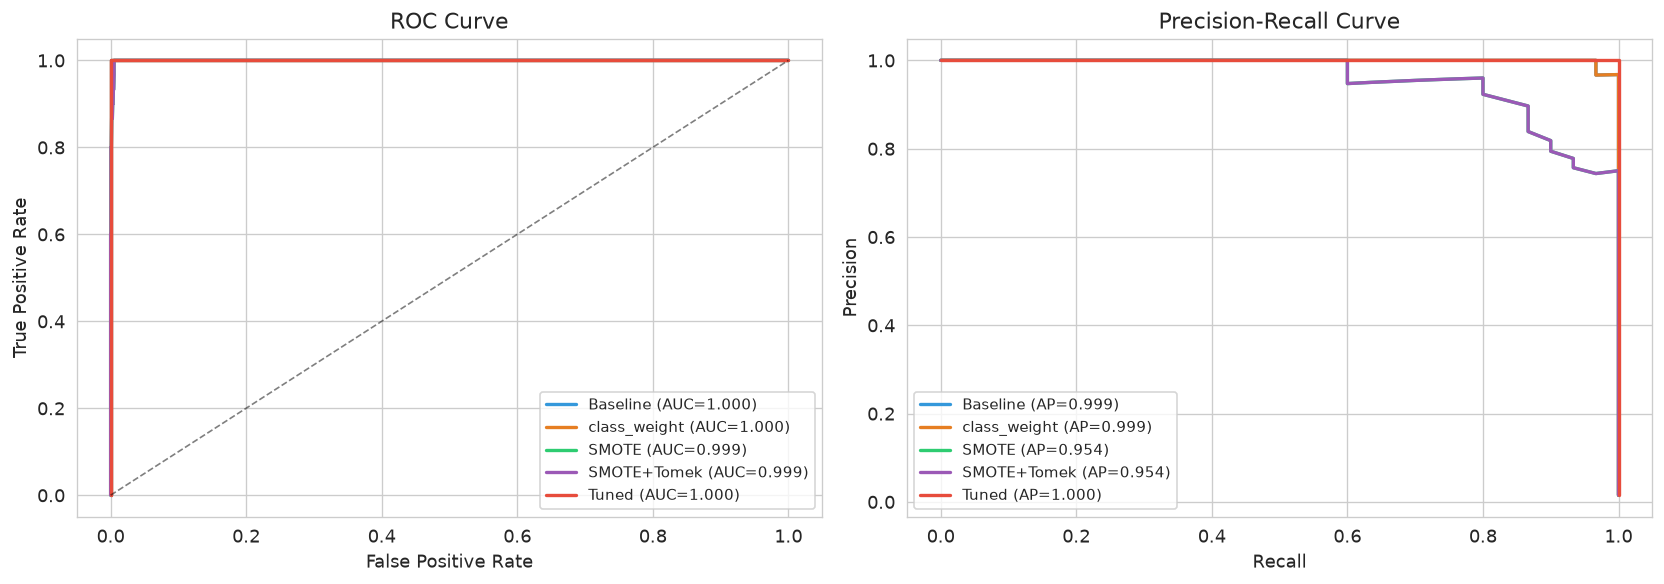

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── ROC Curves ────────────────────────────────────────────────
for name, yprob, color in [
    ('Baseline',   y_prob_base,  '#3498db'),
    ('class_weight', y_prob_cw,  '#e67e22'),
    ('SMOTE',      y_prob_sm,    '#2ecc71'),
    ('SMOTE+Tomek', y_prob_smt,  '#9b59b6'),
    ('Tuned',      y_prob_tuned, '#e74c3c'),
]:
    fpr, tpr, _ = roc_curve(y_test, yprob)
    auc = roc_auc_score(y_test, yprob)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, lw=2)

axes[0].plot([0,1], [0,1], 'k--', lw=1, alpha=0.5)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(fontsize=9)

# ── Precision-Recall Curves ───────────────────────────────────
for name, yprob, color in [
    ('Baseline',   y_prob_base,  '#3498db'),
    ('class_weight', y_prob_cw,  '#e67e22'),
    ('SMOTE',      y_prob_sm,    '#2ecc71'),
    ('SMOTE+Tomek', y_prob_smt,  '#9b59b6'),
    ('Tuned',      y_prob_tuned, '#e74c3c'),
]:
    prec, rec, _ = precision_recall_curve(y_test, yprob)
    ap = average_precision_score(y_test, yprob)
    axes[1].plot(rec, prec, label=f'{name} (AP={ap:.3f})', color=color, lw=2)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

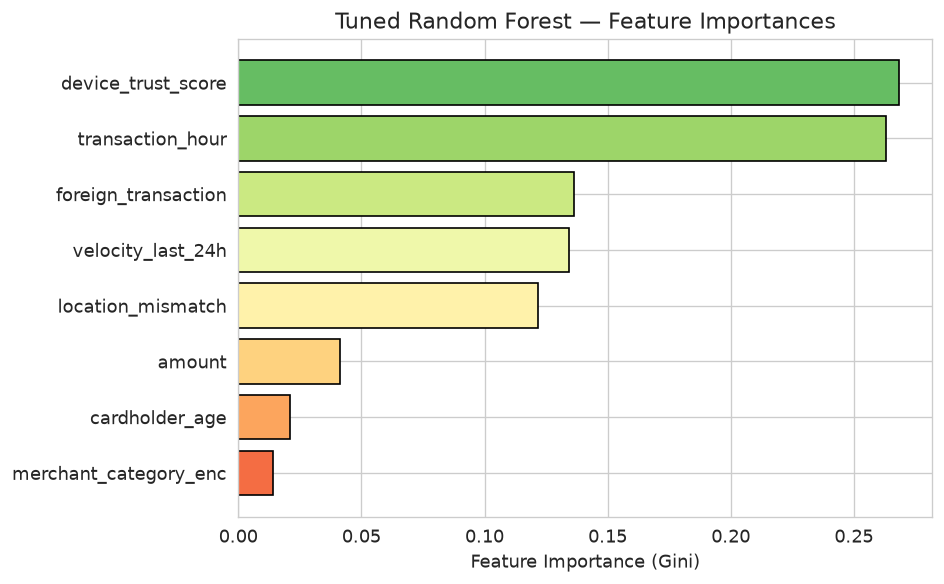

In [15]:
# ── Feature importance (tuned model) ──────────────────────────
importances = rf_tuned.feature_importances_
sorted_idx = np.argsort(importances)

fig, ax = plt.subplots(figsize=(8, 5))
colors_fi = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(feature_cols)))
ax.barh(np.array(feature_cols)[sorted_idx], importances[sorted_idx],
        color=colors_fi, edgecolor='black')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Tuned Random Forest — Feature Importances')
plt.tight_layout()
plt.show()

### 2.1 · Generate synthetic non-separable data

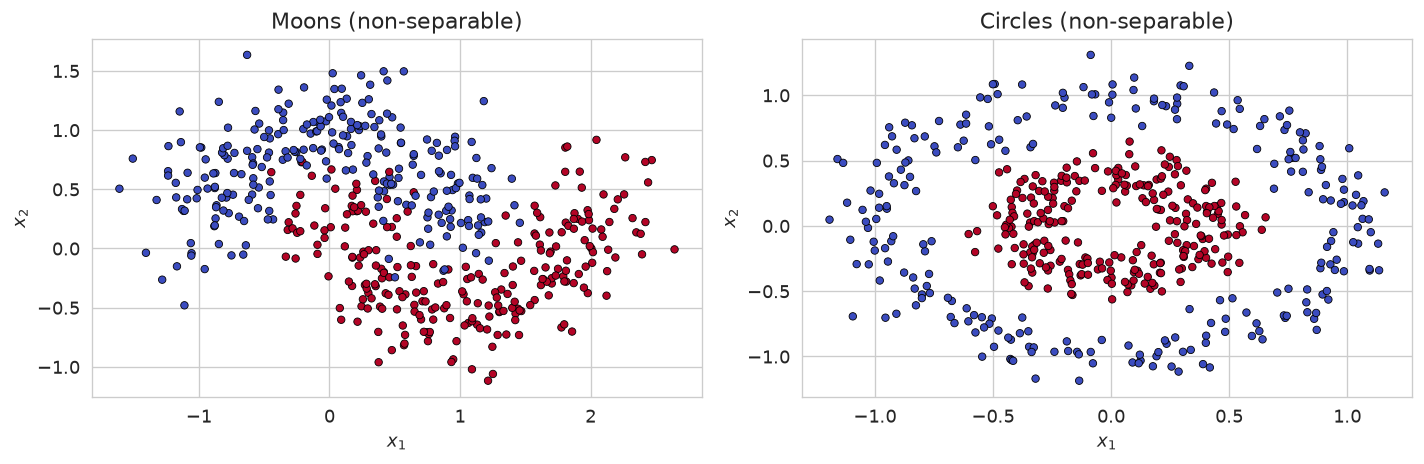

In [16]:
from sklearn.datasets import make_moons, make_circles

# Two classic non-separable datasets
X_moons, y_moons   = make_moons(n_samples=500, noise=0.25, random_state=RANDOM_STATE)
X_circles, y_circles = make_circles(n_samples=500, noise=0.1, factor=0.4, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, X_d, y_d, title in zip(axes,
                                [X_moons, X_circles],
                                [y_moons, y_circles],
                                ['Moons (non-separable)', 'Circles (non-separable)']):
    ax.scatter(X_d[:, 0], X_d[:, 1], c=y_d, cmap='coolwarm', s=20, edgecolors='k', linewidths=0.5)
    ax.set_title(title)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')

plt.tight_layout()
plt.show()

### 2.2 · Train SVMs with different kernels & plot decision boundaries

In [17]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline


def plot_decision_boundary(ax, model, X, y, title=''):
    """Plot the decision boundary, margins, and support vectors."""
    h = 0.02  # mesh step size
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.contour(xx, yy, Z, colors='k', linewidths=0.5)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=15,
               edgecolors='k', linewidths=0.4)

    # Highlight support vectors if available
    if hasattr(model, 'named_steps'):
        svc = model.named_steps['svc']
    else:
        svc = model
    if hasattr(svc, 'support_vectors_'):
        # Transform support vectors back if pipeline was used
        sv = svc.support_vectors_
        if hasattr(model, 'named_steps'):
            sv = model.named_steps['standardscaler'].inverse_transform(sv)
        ax.scatter(sv[:, 0], sv[:, 1], s=80, facecolors='none',
                   edgecolors='yellow', linewidths=1.5, label='Support Vectors')

    ax.set_title(title, fontsize=11)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')


print('Helper function defined.')

Helper function defined.


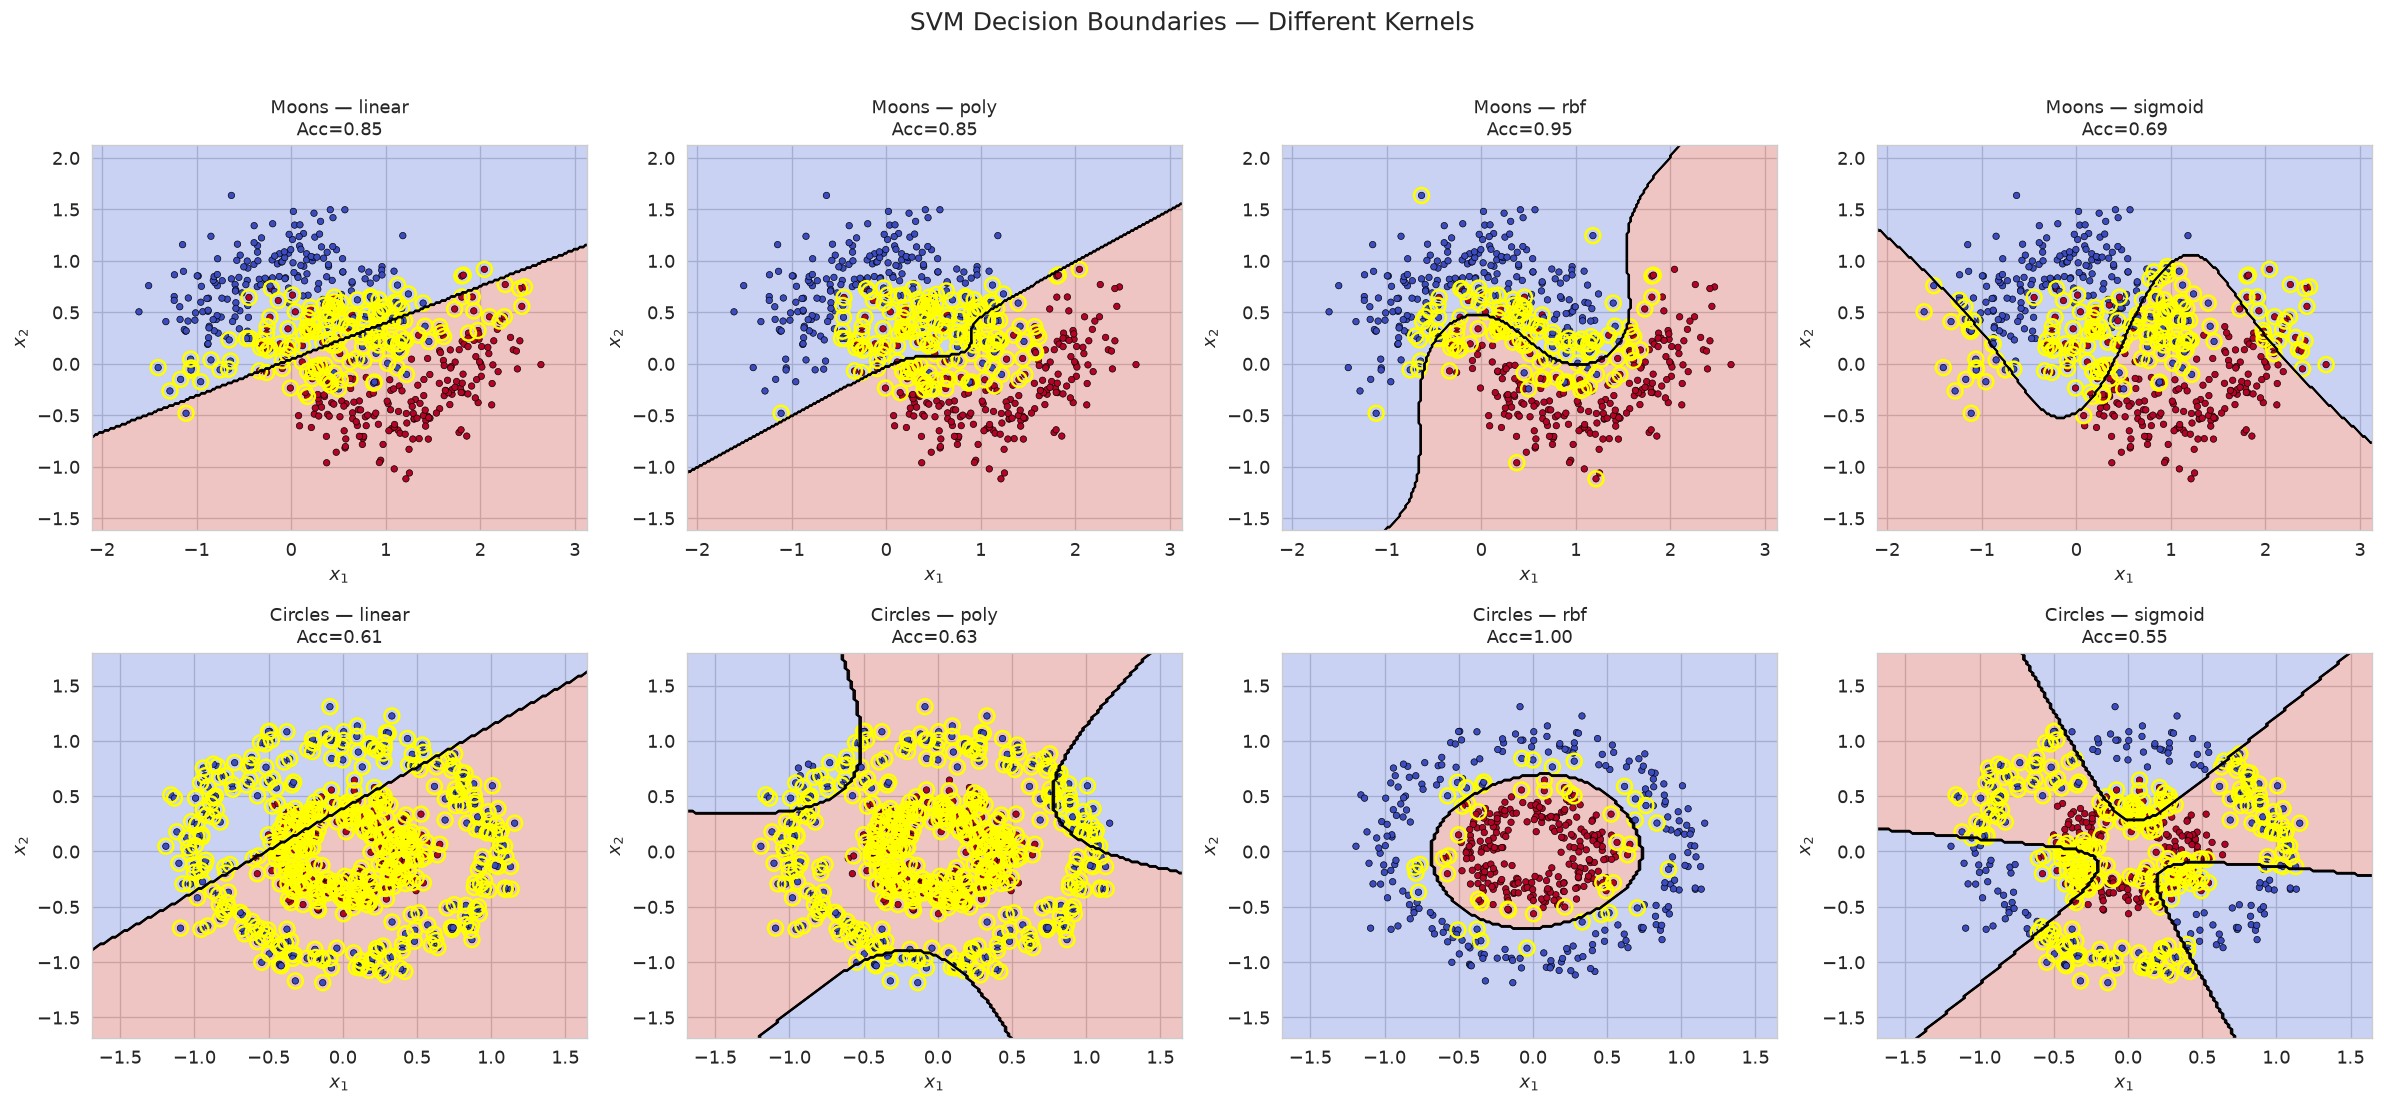

In [18]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle('SVM Decision Boundaries — Different Kernels', fontsize=15, y=1.02)

for col, kernel in enumerate(kernels):
    for row, (X_d, y_d, dname) in enumerate([
        (X_moons,   y_moons,   'Moons'),
        (X_circles, y_circles, 'Circles'),
    ]):
        svm = make_pipeline(StandardScaler(), SVC(kernel=kernel, C=1.0, gamma='scale'))
        svm.fit(X_d, y_d)
        acc = svm.score(X_d, y_d)
        plot_decision_boundary(axes[row, col], svm, X_d, y_d,
                               title=f'{dname} — {kernel}\nAcc={acc:.2f}')

plt.tight_layout()
plt.show()

### 2.4 · Train/test evaluation with the best SVM

Best CV Accuracy: 0.9493
Best params:      {'svc__C': 1, 'svc__gamma': 1}
Test Accuracy:    0.9600


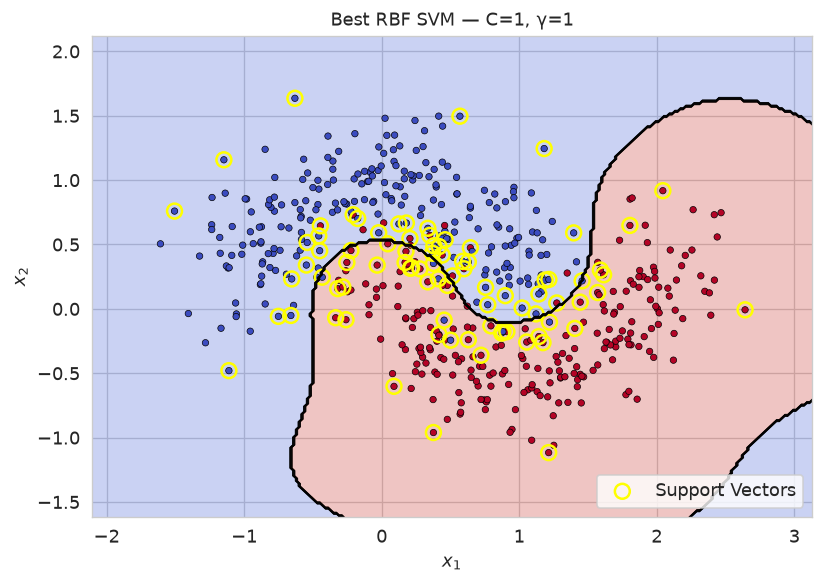

In [20]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'svc__C':     [0.1, 1, 10, 100],
    'svc__gamma': ['scale', 'auto', 0.1, 1, 10],
}

svm_pipe = make_pipeline(StandardScaler(), SVC(kernel='rbf'))

X_moon_train, X_moon_test, y_moon_train, y_moon_test = train_test_split(
    X_moons, y_moons, test_size=0.25, random_state=RANDOM_STATE
)

grid = GridSearchCV(svm_pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_moon_train, y_moon_train)

print(f'Best CV Accuracy: {grid.best_score_:.4f}')
print(f'Best params:      {grid.best_params_}')
print(f'Test Accuracy:    {grid.score(X_moon_test, y_moon_test):.4f}')

# Final decision boundary
fig, ax = plt.subplots(figsize=(7, 5))
plot_decision_boundary(ax, grid.best_estimator_, X_moons, y_moons,
                       title=f'Best RBF SVM — C={grid.best_params_["svc__C"]}, '
                             f'γ={grid.best_params_["svc__gamma"]}')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 3.1 · Generate synthetic data with anomalies

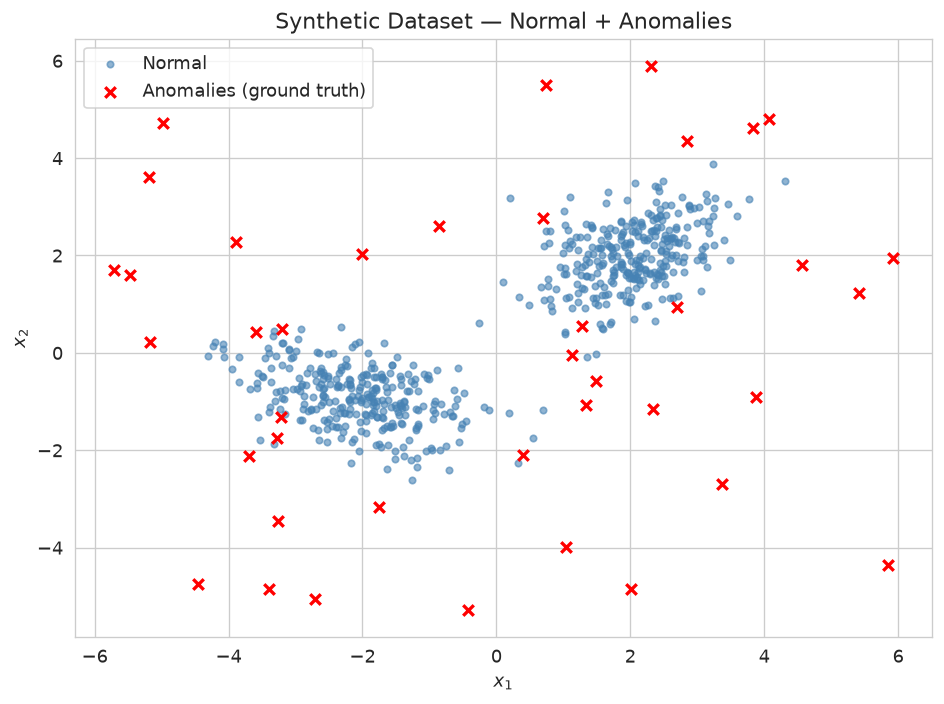

Normal: 600  |  Anomalies: 40  |  Total: 640


In [21]:
from sklearn.mixture import GaussianMixture

np.random.seed(RANDOM_STATE)

# Normal data — two clusters
n_normal = 600
cluster1 = np.random.multivariate_normal([2, 2],  [[0.5, 0.2], [0.2, 0.5]], n_normal // 2)
cluster2 = np.random.multivariate_normal([-2, -1], [[0.8, -0.3], [-0.3, 0.4]], n_normal // 2)
X_normal = np.vstack([cluster1, cluster2])

# Anomalies — scattered outliers
n_anomalies = 40
X_anomalies = np.random.uniform(low=-6, high=6, size=(n_anomalies, 2))

# Combined dataset
X_all = np.vstack([X_normal, X_anomalies])
y_true_labels = np.array([0] * n_normal + [1] * n_anomalies)  # 0=normal, 1=anomaly

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_normal[:, 0], X_normal[:, 1], c='steelblue', s=15, alpha=0.6, label='Normal')
ax.scatter(X_anomalies[:, 0], X_anomalies[:, 1], c='red', s=40, marker='x',
           linewidths=2, label='Anomalies (ground truth)')
ax.set_title('Synthetic Dataset — Normal + Anomalies')
ax.legend()
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
plt.tight_layout()
plt.show()

print(f'Normal: {n_normal}  |  Anomalies: {n_anomalies}  |  Total: {len(X_all)}')

### 3.2 · Select the number of components (BIC / AIC)

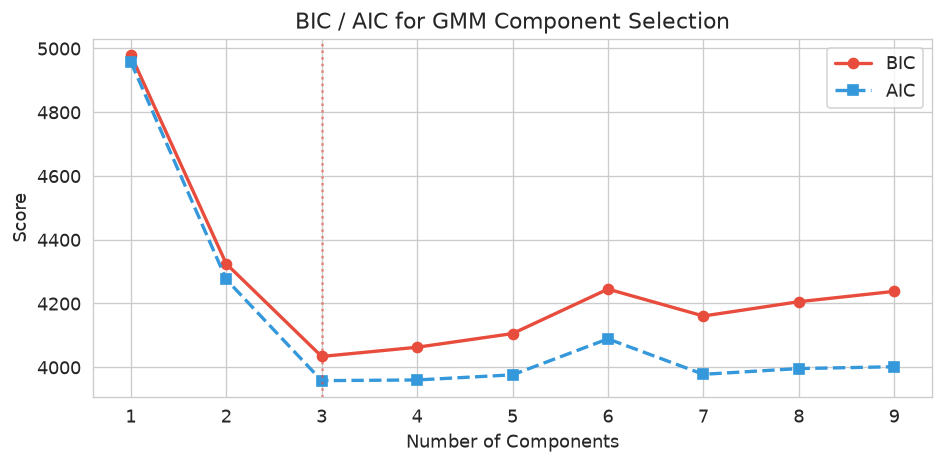

Optimal number of components (BIC): 3


In [22]:
n_components_range = range(1, 10)
bic_scores = []
aic_scores = []

for n in n_components_range:
    gmm_tmp = GaussianMixture(n_components=n, covariance_type='full',
                               random_state=RANDOM_STATE)
    gmm_tmp.fit(X_all)
    bic_scores.append(gmm_tmp.bic(X_all))
    aic_scores.append(gmm_tmp.aic(X_all))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(n_components_range), bic_scores, 'o-', label='BIC', color='#e74c3c', lw=2)
ax.plot(list(n_components_range), aic_scores, 's--', label='AIC', color='#3498db', lw=2)
ax.axvline(x=np.argmin(bic_scores) + 1, color='#e74c3c', ls=':', alpha=0.6)
ax.set_xlabel('Number of Components')
ax.set_ylabel('Score')
ax.set_title('BIC / AIC for GMM Component Selection')
ax.legend()
plt.tight_layout()
plt.show()

best_n = np.argmin(bic_scores) + 1
print(f'Optimal number of components (BIC): {best_n}')

### 3.3 · Fit GMM & compute anomaly scores

In [23]:
gmm = GaussianMixture(n_components=best_n, covariance_type='full',
                       random_state=RANDOM_STATE)
gmm.fit(X_all)

# Log-likelihood score per sample (lower = more anomalous)
log_likelihood = gmm.score_samples(X_all)

# Set threshold at a chosen percentile
threshold_percentile = 5   # flag bottom 5% as anomalies
threshold = np.percentile(log_likelihood, threshold_percentile)

y_pred_anomaly = (log_likelihood < threshold).astype(int)

print(f'Threshold (log-likelihood < {threshold:.2f}) → bottom {threshold_percentile}%')
print(f'Predicted anomalies: {y_pred_anomaly.sum()}')
print(f'Actual anomalies:    {n_anomalies}')

Threshold (log-likelihood < -6.78) → bottom 5%
Predicted anomalies: 32
Actual anomalies:    40


In [24]:
# ── Evaluate anomaly detection ────────────────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

print('=== GMM Anomaly Detection Evaluation ===')
print(f'Precision : {precision_score(y_true_labels, y_pred_anomaly):.4f}')
print(f'Recall    : {recall_score(y_true_labels, y_pred_anomaly):.4f}')
print(f'F1 Score  : {f1_score(y_true_labels, y_pred_anomaly):.4f}')
print()
print('Confusion Matrix:')
cm = confusion_matrix(y_true_labels, y_pred_anomaly)
print(pd.DataFrame(cm, index=['Actual Normal', 'Actual Anomaly'],
                       columns=['Pred Normal', 'Pred Anomaly']))

=== GMM Anomaly Detection Evaluation ===
Precision : 0.9375
Recall    : 0.7500
F1 Score  : 0.8333

Confusion Matrix:
                Pred Normal  Pred Anomaly
Actual Normal           598             2
Actual Anomaly           10            30


### 3.4 · Visualize anomaly detection results

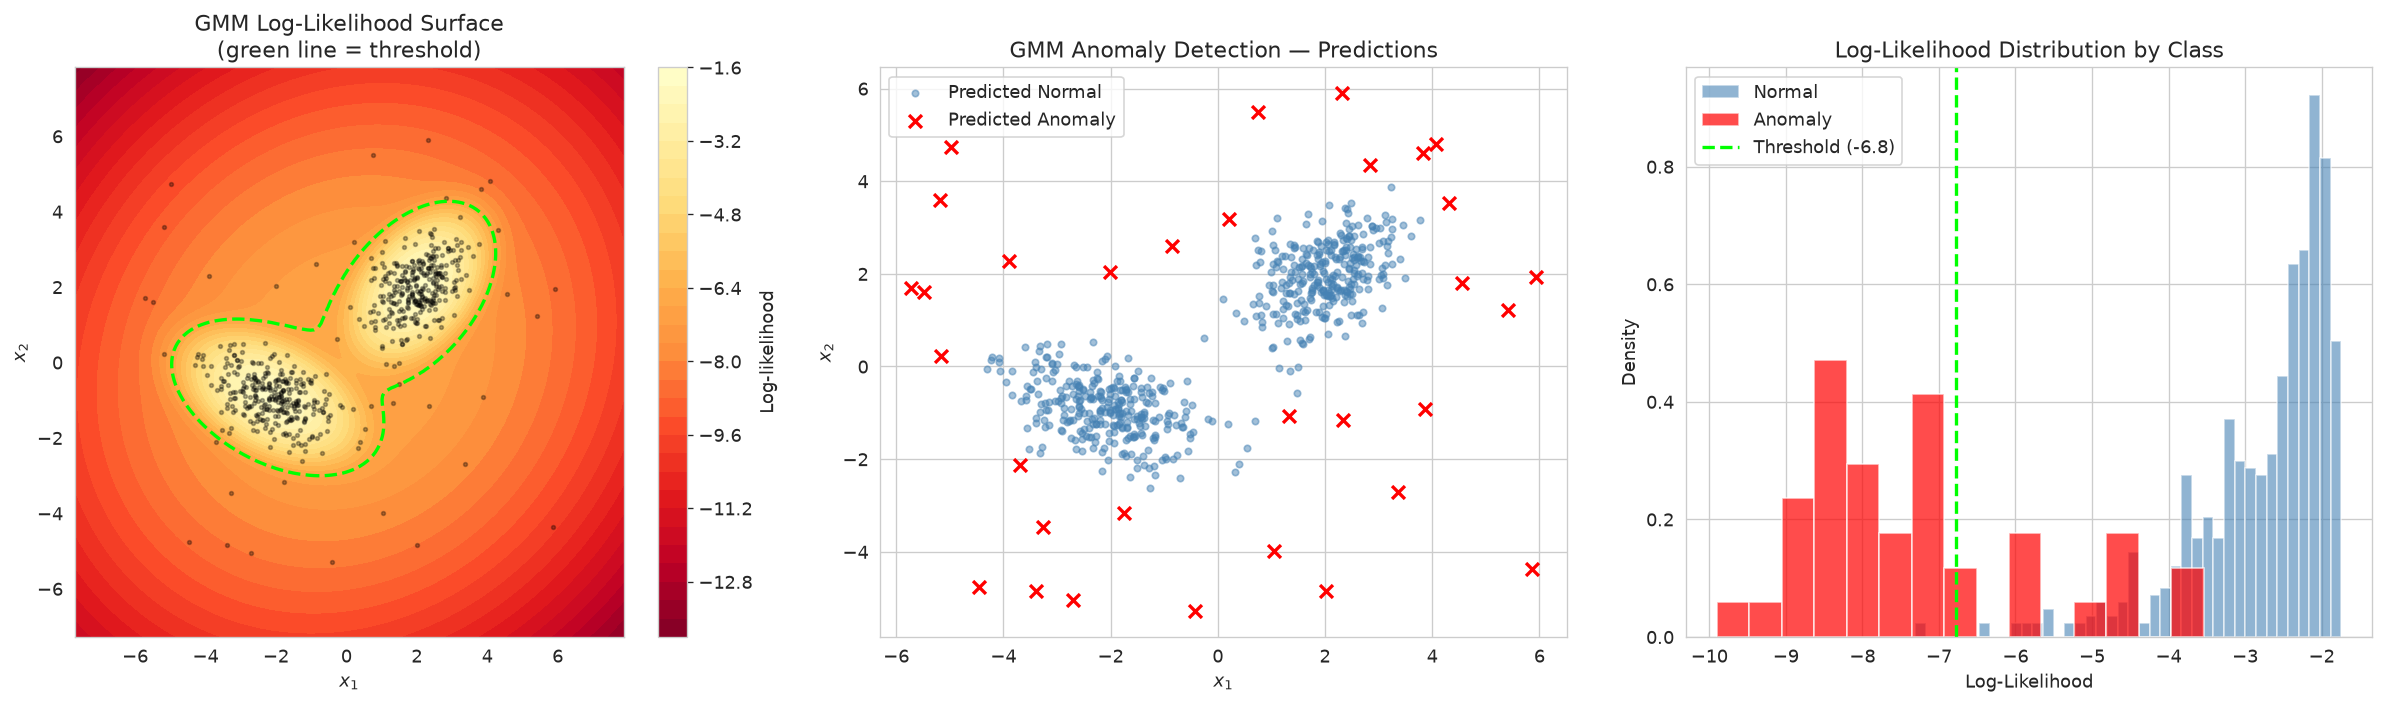

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ── Plot 1: Log-likelihood heatmap ────────────────────────────
ax = axes[0]
h = 0.1
x_min, x_max = X_all[:, 0].min() - 2, X_all[:, 0].max() + 2
y_min, y_max = X_all[:, 1].min() - 2, X_all[:, 1].max() + 2
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = gmm.score_samples(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

cs = ax.contourf(xx, yy, Z, levels=30, cmap='YlOrRd_r')
plt.colorbar(cs, ax=ax, label='Log-likelihood')
ax.scatter(X_all[:, 0], X_all[:, 1], c='black', s=5, alpha=0.3)
ax.contour(xx, yy, Z, levels=[threshold], colors='lime', linewidths=2, linestyles='--')
ax.set_title('GMM Log-Likelihood Surface\n(green line = threshold)')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

# ── Plot 2: Predicted anomalies ───────────────────────────────
ax = axes[1]
normal_mask  = y_pred_anomaly == 0
anomaly_mask = y_pred_anomaly == 1
ax.scatter(X_all[normal_mask, 0], X_all[normal_mask, 1],
           c='steelblue', s=15, alpha=0.5, label='Predicted Normal')
ax.scatter(X_all[anomaly_mask, 0], X_all[anomaly_mask, 1],
           c='red', s=60, marker='x', linewidths=2, label='Predicted Anomaly')
ax.set_title('GMM Anomaly Detection — Predictions')
ax.legend()
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

# ── Plot 3: Log-likelihood distribution ───────────────────────
ax = axes[2]
ax.hist(log_likelihood[y_true_labels == 0], bins=40, alpha=0.6,
        color='steelblue', label='Normal', density=True)
ax.hist(log_likelihood[y_true_labels == 1], bins=15, alpha=0.7,
        color='red', label='Anomaly', density=True)
ax.axvline(threshold, color='lime', ls='--', lw=2, label=f'Threshold ({threshold:.1f})')
ax.set_xlabel('Log-Likelihood')
ax.set_ylabel('Density')
ax.set_title('Log-Likelihood Distribution by Class')
ax.legend()

plt.tight_layout()
plt.show()

### 3.5 · Threshold sensitivity analysis

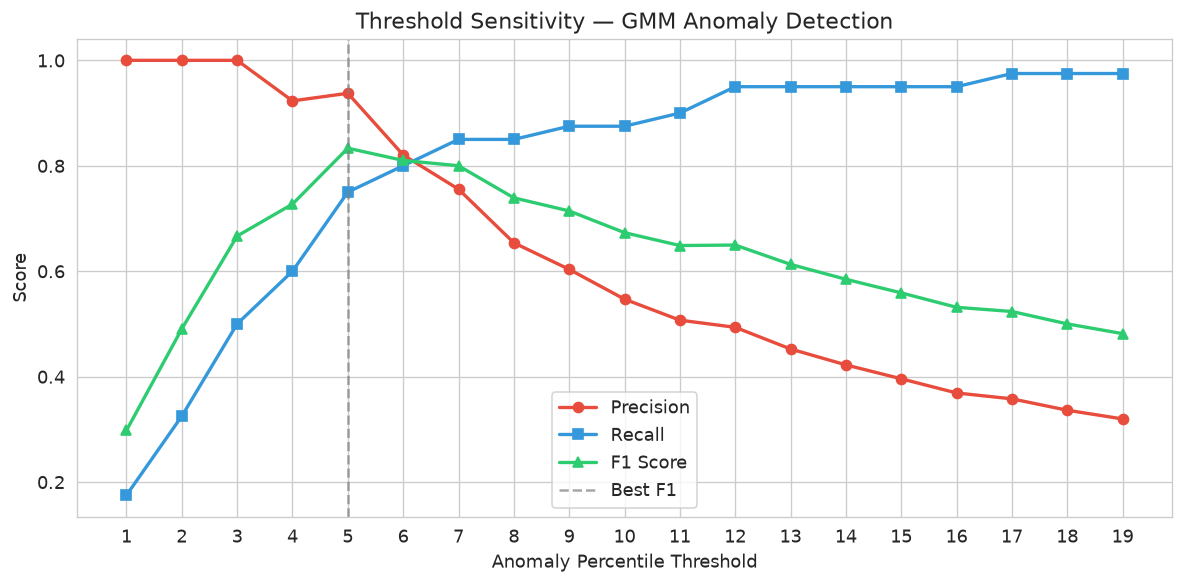

Best threshold: percentile=5  (log-lik < -6.78)  →  F1=0.8333


In [26]:
percentiles = np.arange(1, 20)
results = []

for p in percentiles:
    thr = np.percentile(log_likelihood, p)
    preds = (log_likelihood < thr).astype(int)
    results.append({
        'Percentile': p,
        'Threshold': thr,
        'Precision': precision_score(y_true_labels, preds, zero_division=0),
        'Recall':    recall_score(y_true_labels, preds, zero_division=0),
        'F1':        f1_score(y_true_labels, preds, zero_division=0),
    })

res_df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(res_df['Percentile'], res_df['Precision'], 'o-', label='Precision', color='#e74c3c', lw=2)
ax.plot(res_df['Percentile'], res_df['Recall'],    's-', label='Recall',    color='#3498db', lw=2)
ax.plot(res_df['Percentile'], res_df['F1'],        '^-', label='F1 Score',  color='#2ecc71', lw=2)
ax.axvline(res_df.loc[res_df['F1'].idxmax(), 'Percentile'],
           color='gray', ls='--', alpha=0.7, label='Best F1')
ax.set_xlabel('Anomaly Percentile Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold Sensitivity — GMM Anomaly Detection')
ax.legend()
ax.set_xticks(percentiles)
plt.tight_layout()
plt.show()

best_row = res_df.loc[res_df['F1'].idxmax()]
print(f"Best threshold: percentile={best_row['Percentile']:.0f}  "
      f"(log-lik < {best_row['Threshold']:.2f})  →  F1={best_row['F1']:.4f}")

### 3.6 · GMM on the real fraud data (bonus)

Best n_components for fraud data (BIC): 7


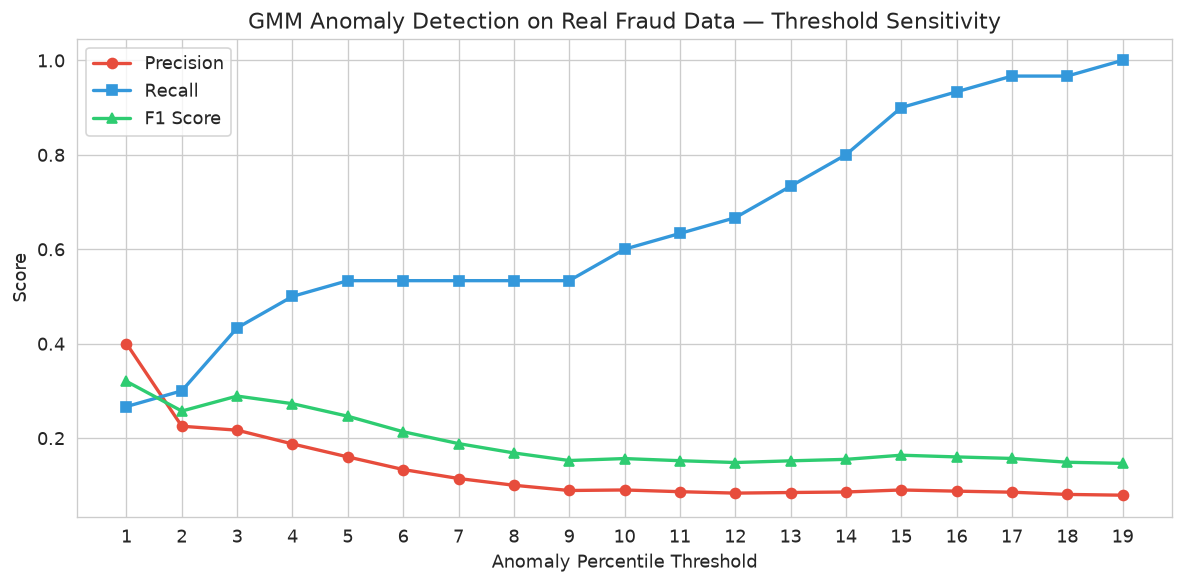


Best: percentile=1  →  Precision=0.400, Recall=0.267, F1=0.320


In [27]:
# Fit GMM on the scaled training data (only non-fraud to learn "normal" pattern)
X_train_normal = X_train_scaled[y_train == 0]

# Select best n_components via BIC
bics = []
for n in range(1, 8):
    g = GaussianMixture(n_components=n, covariance_type='full', random_state=RANDOM_STATE)
    g.fit(X_train_normal)
    bics.append(g.bic(X_train_normal))

best_n_fraud = np.argmin(bics) + 1
print(f'Best n_components for fraud data (BIC): {best_n_fraud}')

gmm_fraud = GaussianMixture(n_components=best_n_fraud, covariance_type='full',
                             random_state=RANDOM_STATE)
gmm_fraud.fit(X_train_normal)

# Score test set
ll_test = gmm_fraud.score_samples(X_test_scaled)

# Try different thresholds
res_fraud = []
for p in range(1, 20):
    thr = np.percentile(ll_test, p)
    preds = (ll_test < thr).astype(int)
    res_fraud.append({
        'Percentile': p,
        'Precision': precision_score(y_test, preds, zero_division=0),
        'Recall':    recall_score(y_test, preds, zero_division=0),
        'F1':        f1_score(y_test, preds, zero_division=0),
    })

res_fraud_df = pd.DataFrame(res_fraud)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(res_fraud_df['Percentile'], res_fraud_df['Precision'], 'o-', label='Precision', color='#e74c3c', lw=2)
ax.plot(res_fraud_df['Percentile'], res_fraud_df['Recall'],    's-', label='Recall',    color='#3498db', lw=2)
ax.plot(res_fraud_df['Percentile'], res_fraud_df['F1'],        '^-', label='F1 Score',  color='#2ecc71', lw=2)
ax.set_xlabel('Anomaly Percentile Threshold')
ax.set_ylabel('Score')
ax.set_title('GMM Anomaly Detection on Real Fraud Data — Threshold Sensitivity')
ax.legend()
ax.set_xticks(range(1, 20))
plt.tight_layout()
plt.show()

best = res_fraud_df.loc[res_fraud_df['F1'].idxmax()]
print(f"\nBest: percentile={best['Percentile']:.0f}  →  "
      f"Precision={best['Precision']:.3f}, Recall={best['Recall']:.3f}, F1={best['F1']:.3f}")